In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/sebastiangutierrezbernal/Desktop/Personal/Quantum Research/info-patterns-repo


In [3]:
from src.parameters import (ELLIPSOID_GEOMETRY_PARAMS, DEFAULT_MATERIAL_NAME, DEFAULT_MATERIAL_KWARGS, DEFAULT_WAVELENGTH_NM, FAST_FARFIELD_PARAMS, DEFAULT_DYADS_PARAMS, DEFAULT_COM_DISPLACEMENT_NM, 
                            DEFAULT_LIBRATION_ANGLE_DEG, DEFAULT_USETEX, DEFAULT_FONT_FAMILY, DEFAULT_FIGSIZE, DEFAULT_SAVE_TYPE, DEFAULT_2D_PLANES, DEFAULT_2D_NORMALIZE, DEFAULT_2D_FILL)
from src.constants import (C, EPS0, NM_TO_M)
from src.generate_nanoparticle import (nanoparticle_geometry, nanoparticle_material, nanoparticle_mass)
from src.light_matter_interaction_simulation import (incident_field, field_propagation, simulation_from_geometry, scattered_farfield_from_simulation, librational_scattered_farfield)
from src.information_patterns_simulation import (info_patterns_from_scattered_field)
from src.specific_incident_fields import (parabolic_mirror_efield)
from src.plots import (set_plot_style, plot3d_info_patterns, plot2d_info_patterns)

set_plot_style(usetex=DEFAULT_USETEX, font_family=DEFAULT_FONT_FAMILY, figsize=DEFAULT_FIGSIZE)
results_dir = "lib_ellipse_results"

In [4]:
geometry = nanoparticle_geometry(**ELLIPSOID_GEOMETRY_PARAMS)
material = nanoparticle_material(DEFAULT_MATERIAL_NAME, **DEFAULT_MATERIAL_KWARGS)
step_nm = ELLIPSOID_GEOMETRY_PARAMS["step_nm"]

In [5]:
wavelength_nm = DEFAULT_WAVELENGTH_NM

n_medium = 1.0
f = 1.0e6
power_W = 1e-3

num_app_NA = 0.994475
theta_size = 300

xSpot = 0.0
ySpot = 0.0
zSpot = 0.0

alpha_0 = 0.0
alpha_1 = np.arcsin(num_app_NA / n_medium)

r0_nm = 2 * f * np.tan(alpha_0 / 2)
r1_nm = 2 * f * np.tan(alpha_1 / 2)

w0_nm = 1.5 * r1_nm

r0_m = r0_nm * NM_TO_M
r1_m = r1_nm * NM_TO_M
w0_m = w0_nm * NM_TO_M

delta_exps = (np.exp(-2 * r0_m**2 / w0_m**2) - np.exp(-2 * r1_m**2 / w0_m**2))
N_physical = np.sqrt(4 * power_W / (n_medium * EPS0 * C * np.pi * w0_m**2 * delta_exps))
parabolic_mirror_field_params = {"field_generator": parabolic_mirror_efield, "wavelengths": [wavelength_nm], "n_medium": n_medium, "f": f, "alpha_0": alpha_0, "alpha_1": alpha_1, 
                                 "w_0": w0_nm, "N": N_physical, "theta_size": theta_size, "xSpot": xSpot, "ySpot": ySpot, "zSpot": zSpot}

farfield_params = FAST_FARFIELD_PARAMS
Nteta = farfield_params["Nteta"]
Nphi = farfield_params["Nphi"]
field_index = farfield_params["field_index"]
r = farfield_params["r"]

disp_nm = DEFAULT_COM_DISPLACEMENT_NM
angle_deg = DEFAULT_LIBRATION_ANGLE_DEG

efield = incident_field(**parabolic_mirror_field_params)
dyads = field_propagation(**DEFAULT_DYADS_PARAMS)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 1792.5ms, inv.: 956.3ms, repropa.: 162.4ms (1 field configs), tot: 2911.6ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 104.1ms, inv.: 918.7ms, repropa.: 147.9ms (1 field configs), tot: 1170.9ms


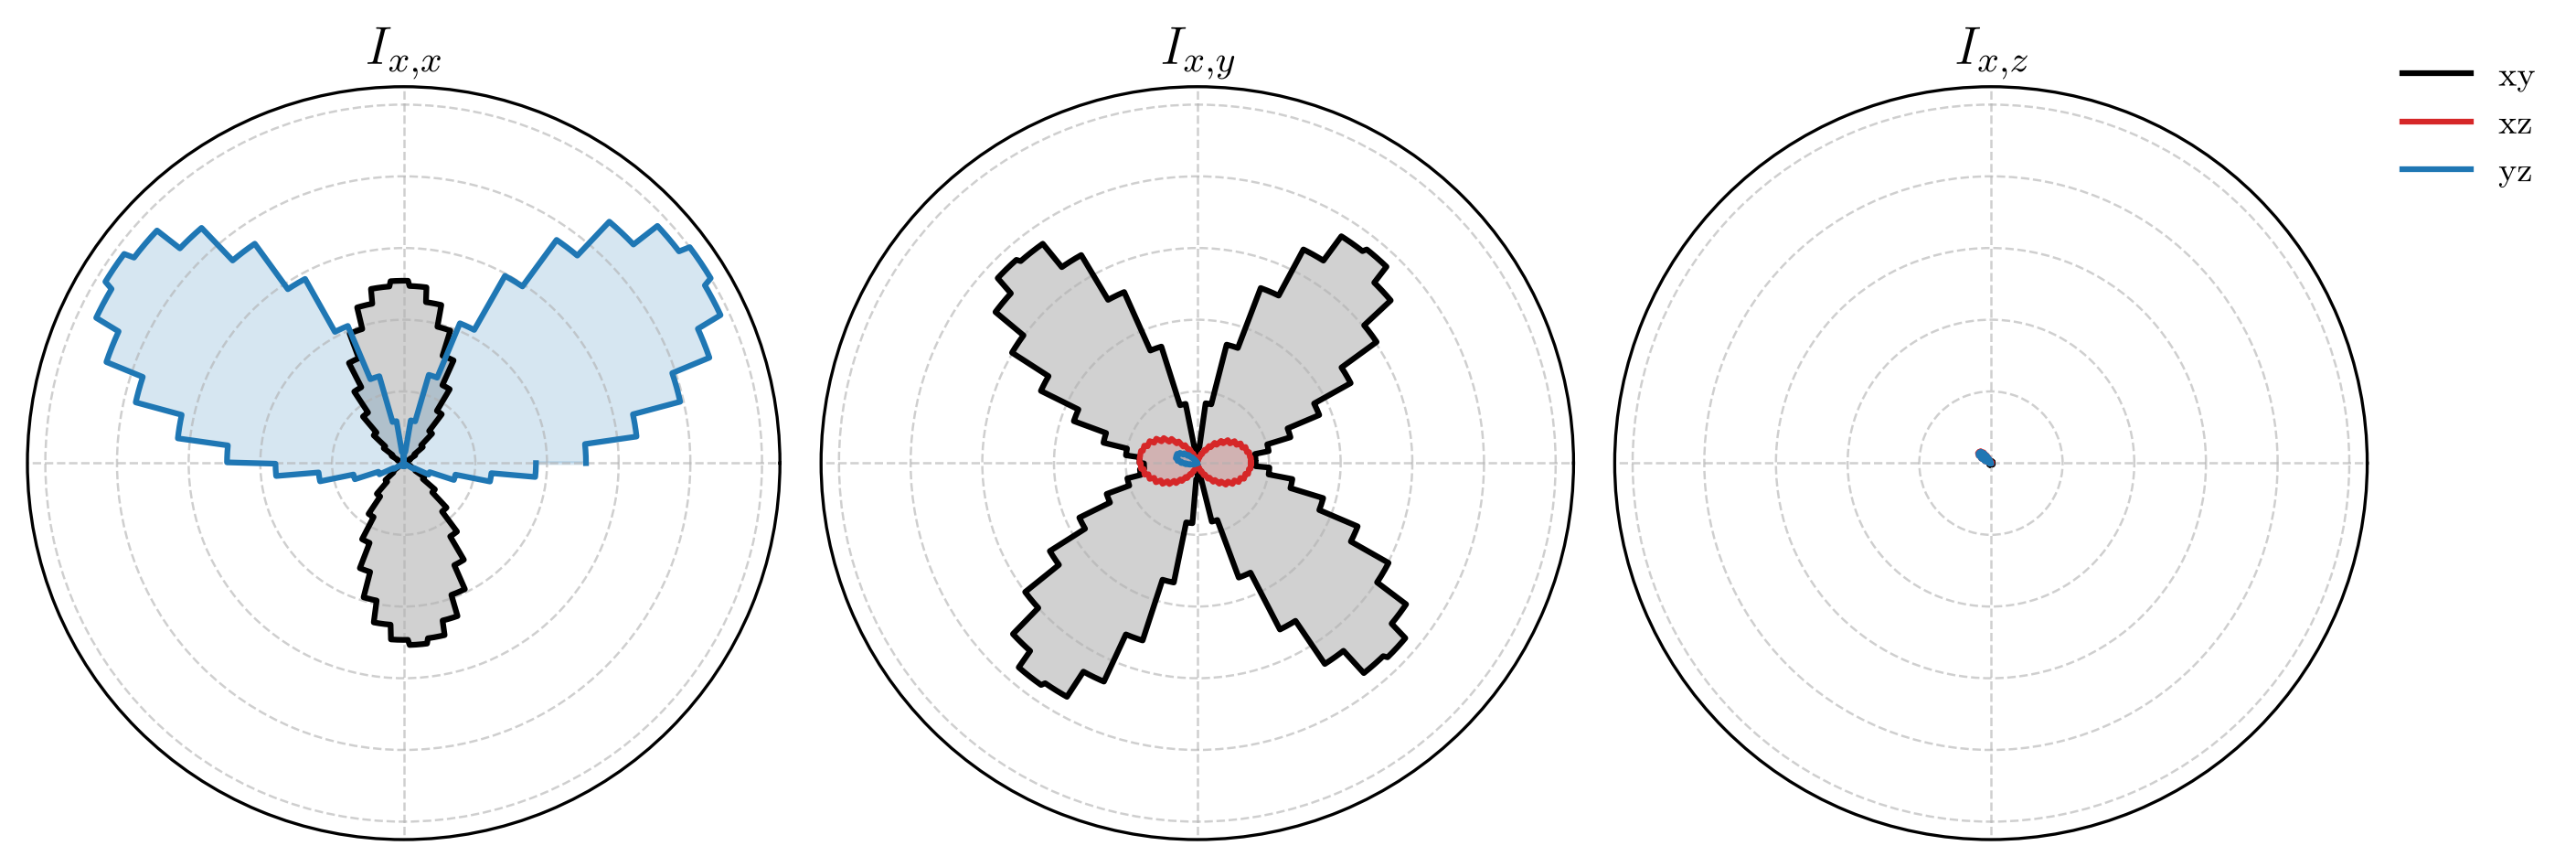

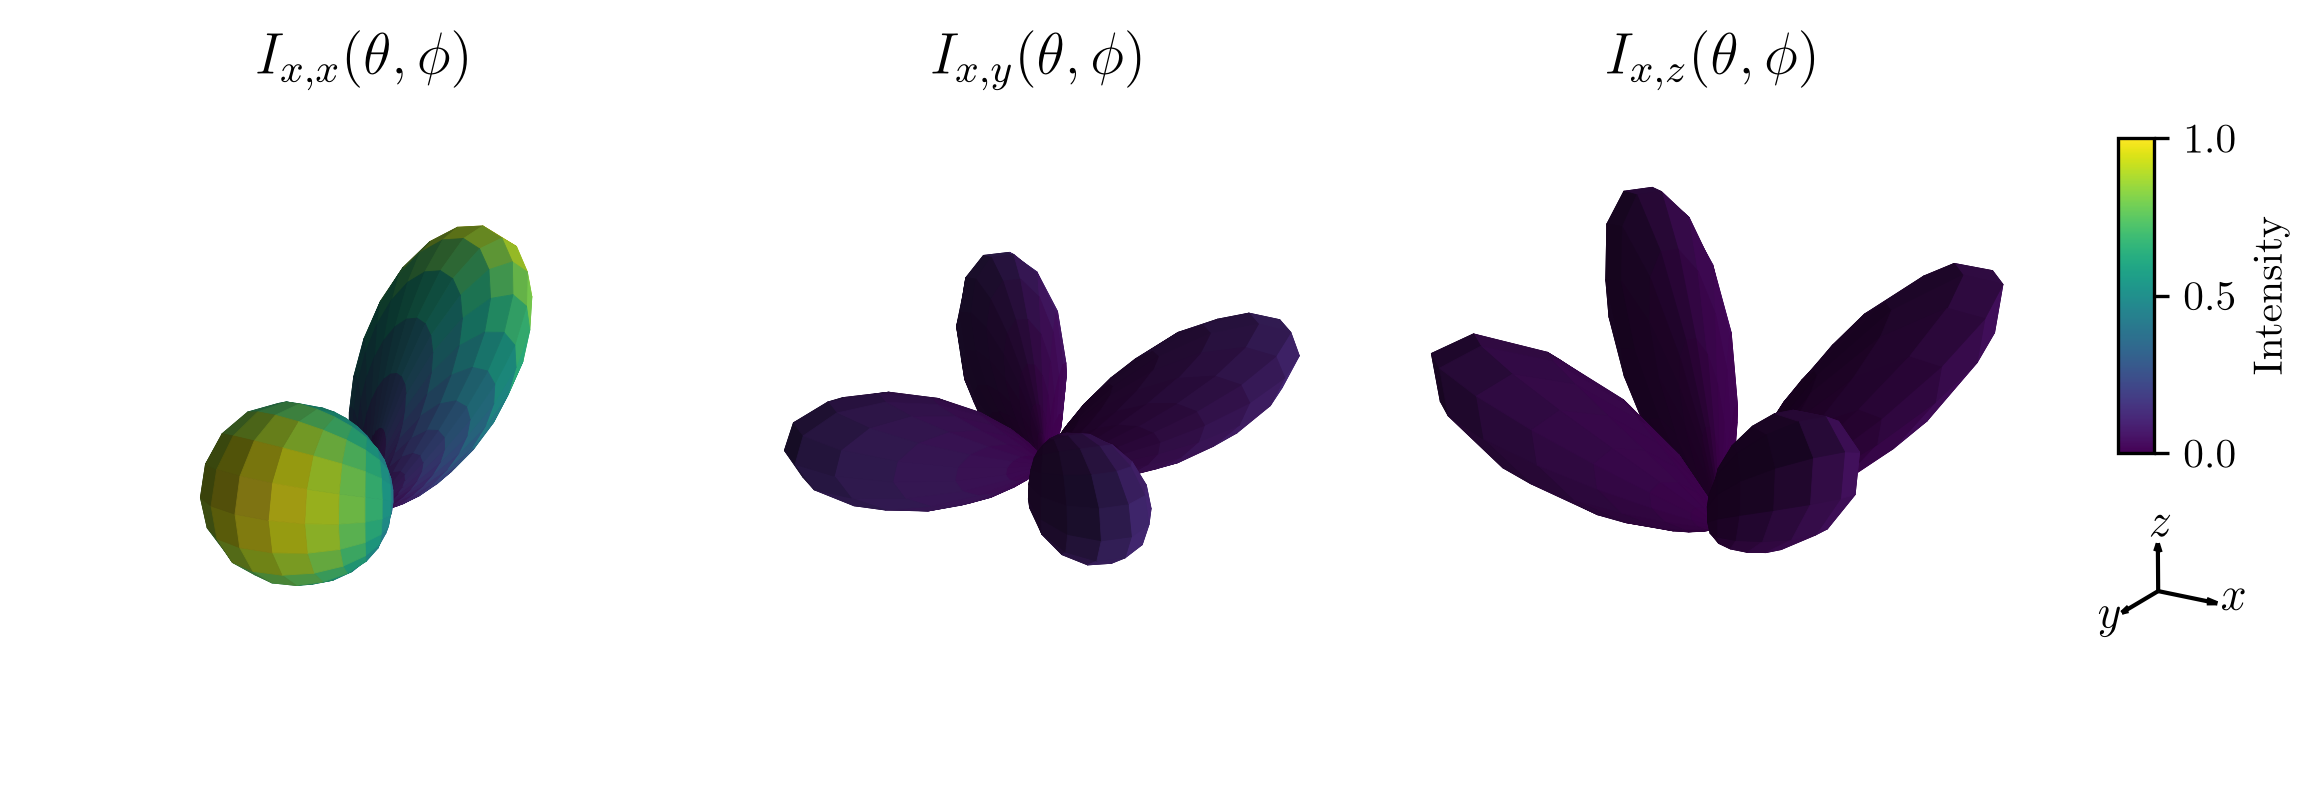

In [6]:
E_lib_plus_x, E_lib_minus_x, dE_lib_x = librational_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=0, angle_deg=angle_deg, 
                                                                       Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_lib_x_total, I_lib_x_Ex, I_lib_x_Ey, I_lib_x_Ez = info_patterns_from_scattered_field(dE=dE_lib_x, delta_mu=angle_deg, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_Ex, I_lib_x_Ey, I_lib_x_Ez], labels=["x,x", "x,y", "x,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_x_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_Ex, I_lib_x_Ey, I_lib_x_Ez], labels=["x,x", "x,y", "x,z"], cmap=cm.viridis, 
                     scale_list=[0.3, 0.38, 0.38], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_x_3d", results_dir=results_dir)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 140.7ms, inv.: 987.2ms, repropa.: 174.1ms (1 field configs), tot: 1302.6ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 130.6ms, inv.: 1207.7ms, repropa.: 179.9ms (1 field configs), tot: 1518.6ms


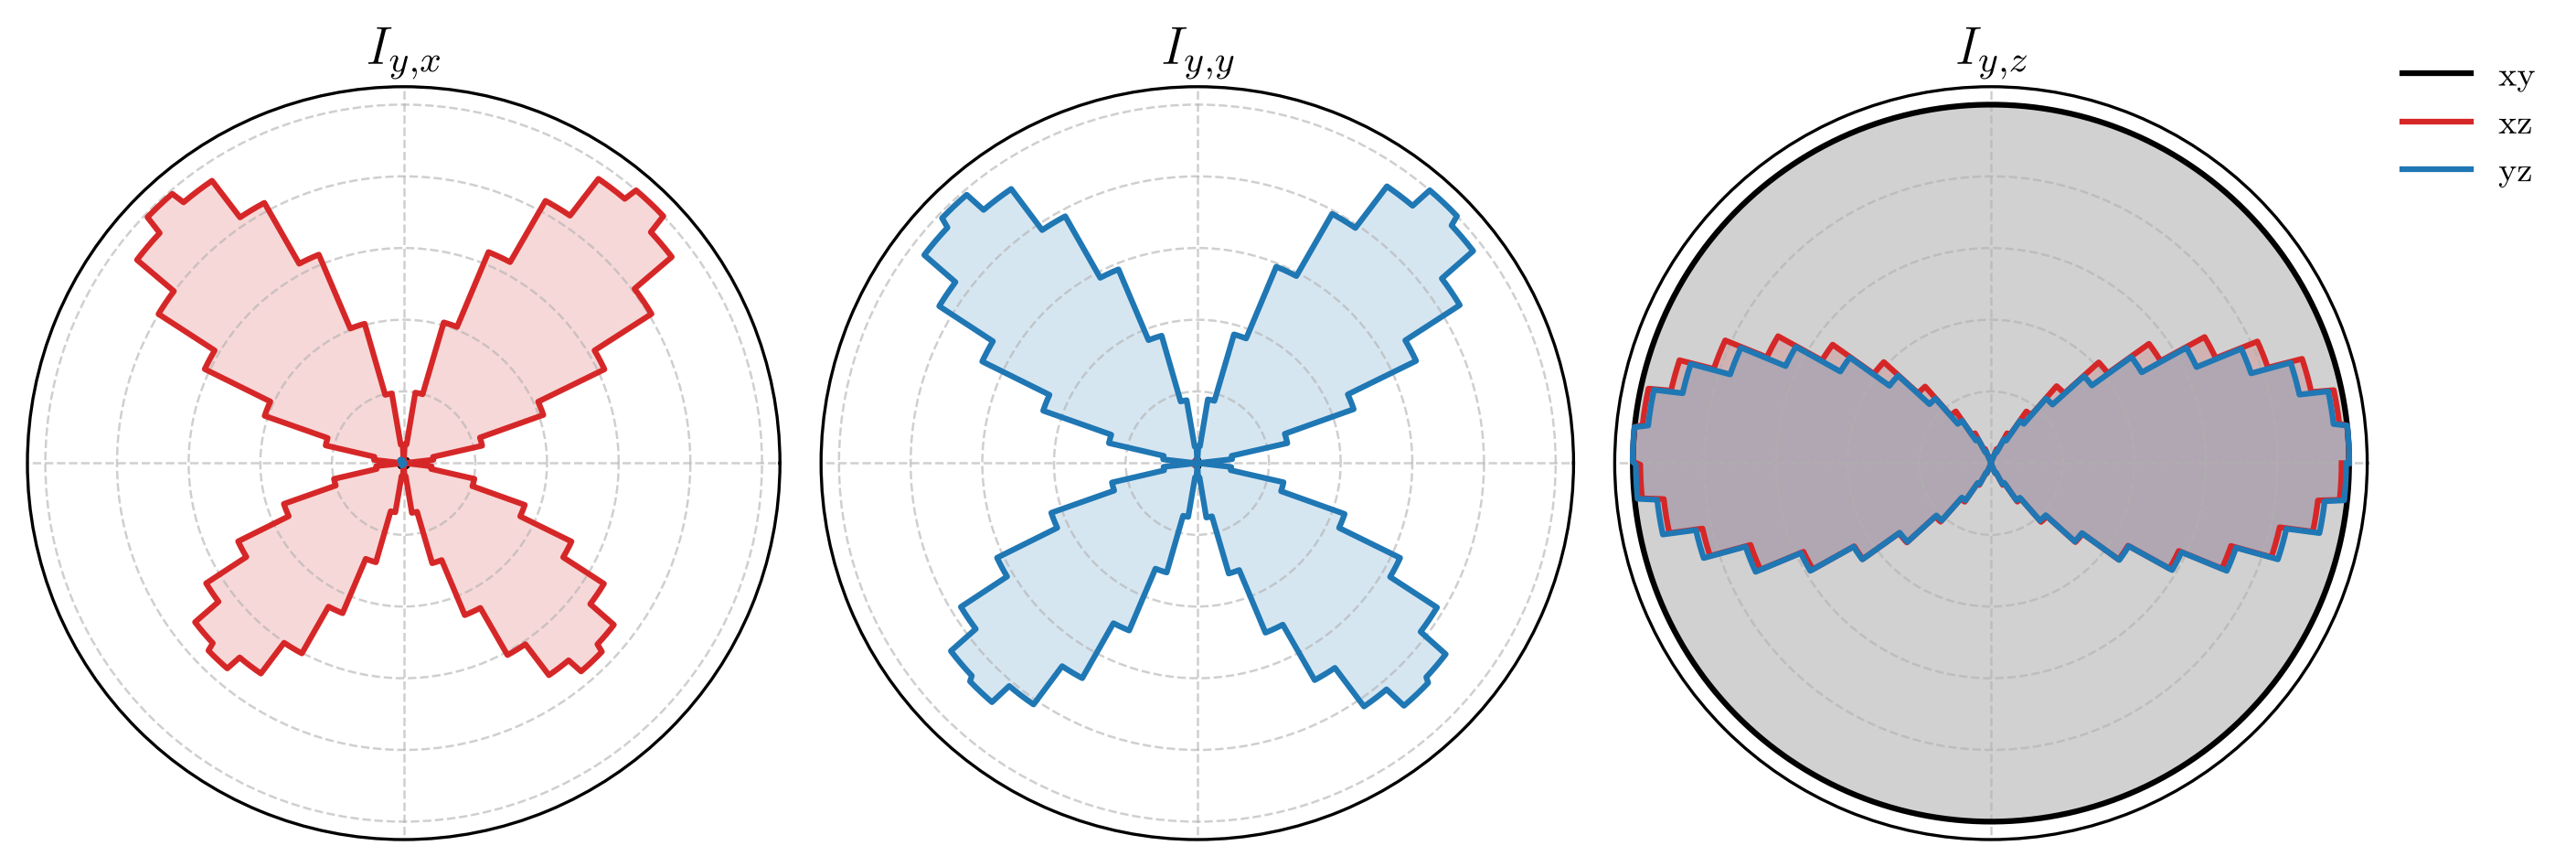

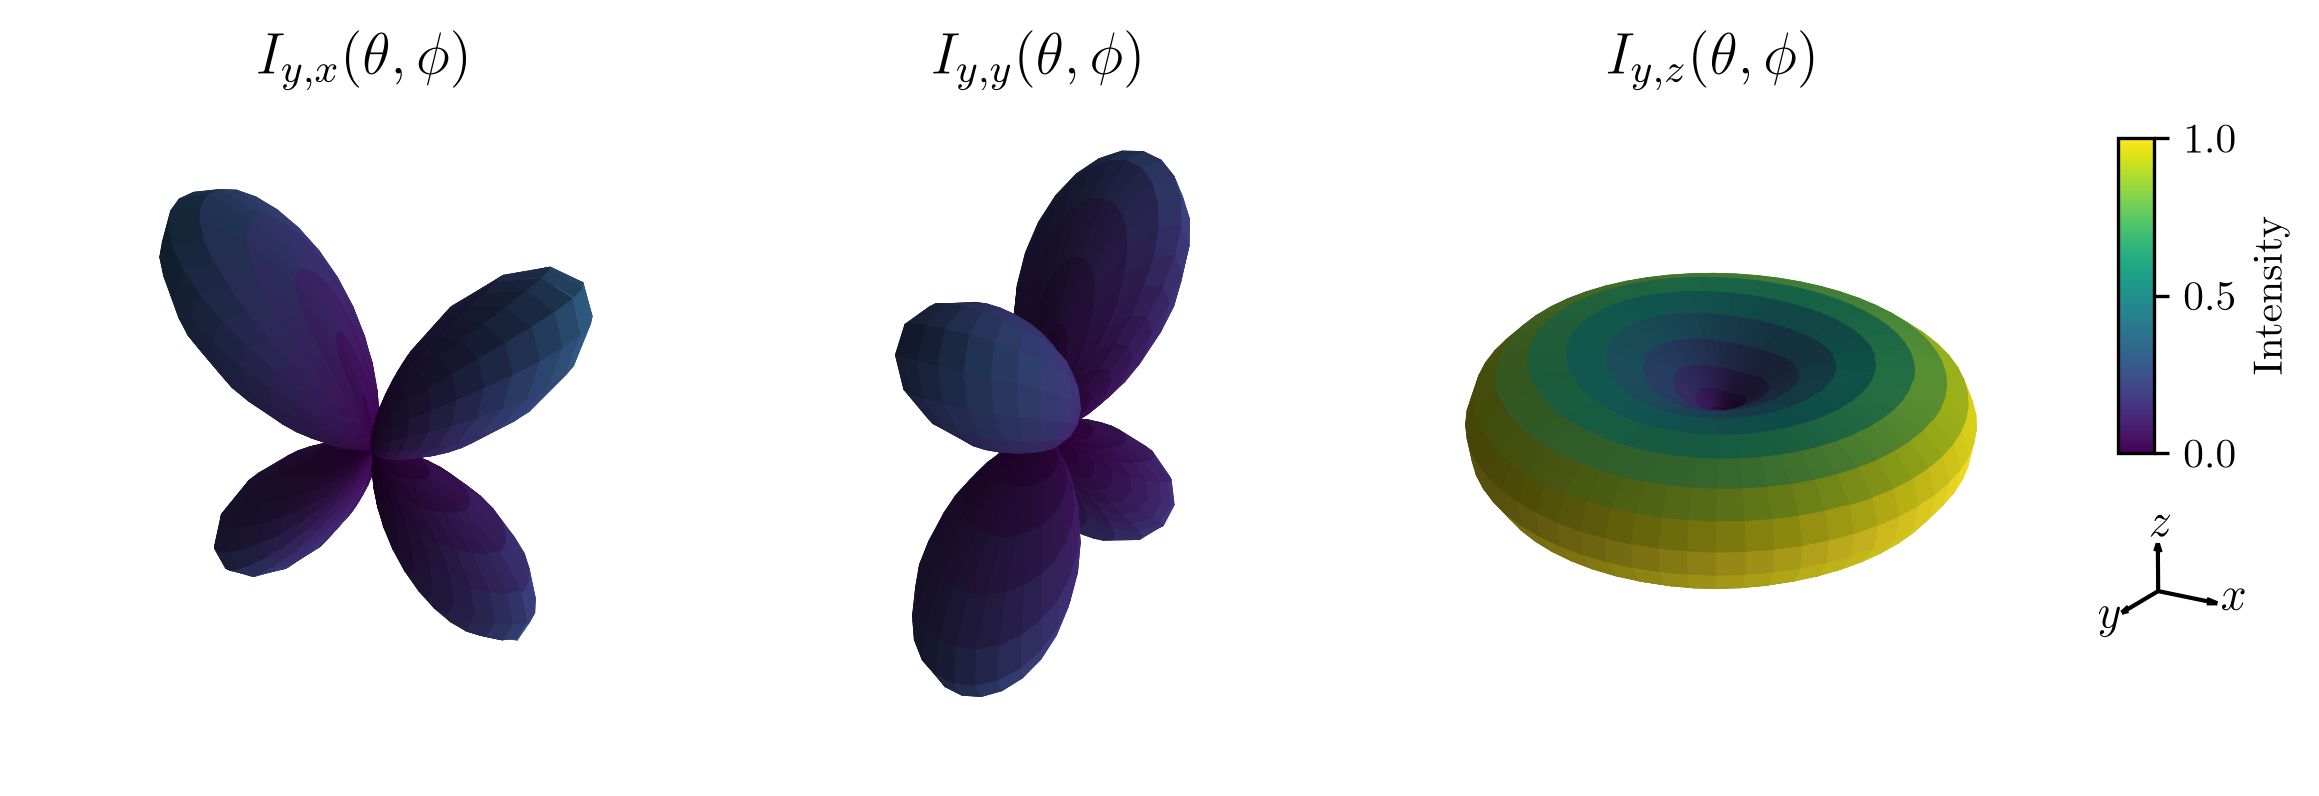

In [7]:
E_lib_plus_y, E_lib_minus_y, dE_lib_y = librational_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=1, angle_deg=angle_deg, 
                                                                       Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_lib_y_total, I_lib_y_Ex, I_lib_y_Ey, I_lib_y_Ez = info_patterns_from_scattered_field(dE=dE_lib_y, delta_mu=angle_deg, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_y_Ex, I_lib_y_Ey, I_lib_y_Ez], labels=["y,x", "y,y", "y,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_y_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_y_Ex, I_lib_y_Ey, I_lib_y_Ez], labels=["y,x", "y,y", "y,z"], cmap=cm.viridis, scale_list=[0.38, 0.38, 0.34], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_y_3d", results_dir=results_dir)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 84.7ms, inv.: 946.9ms, repropa.: 155.0ms (1 field configs), tot: 1186.7ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 93.9ms, inv.: 962.7ms, repropa.: 147.6ms (1 field configs), tot: 1204.4ms


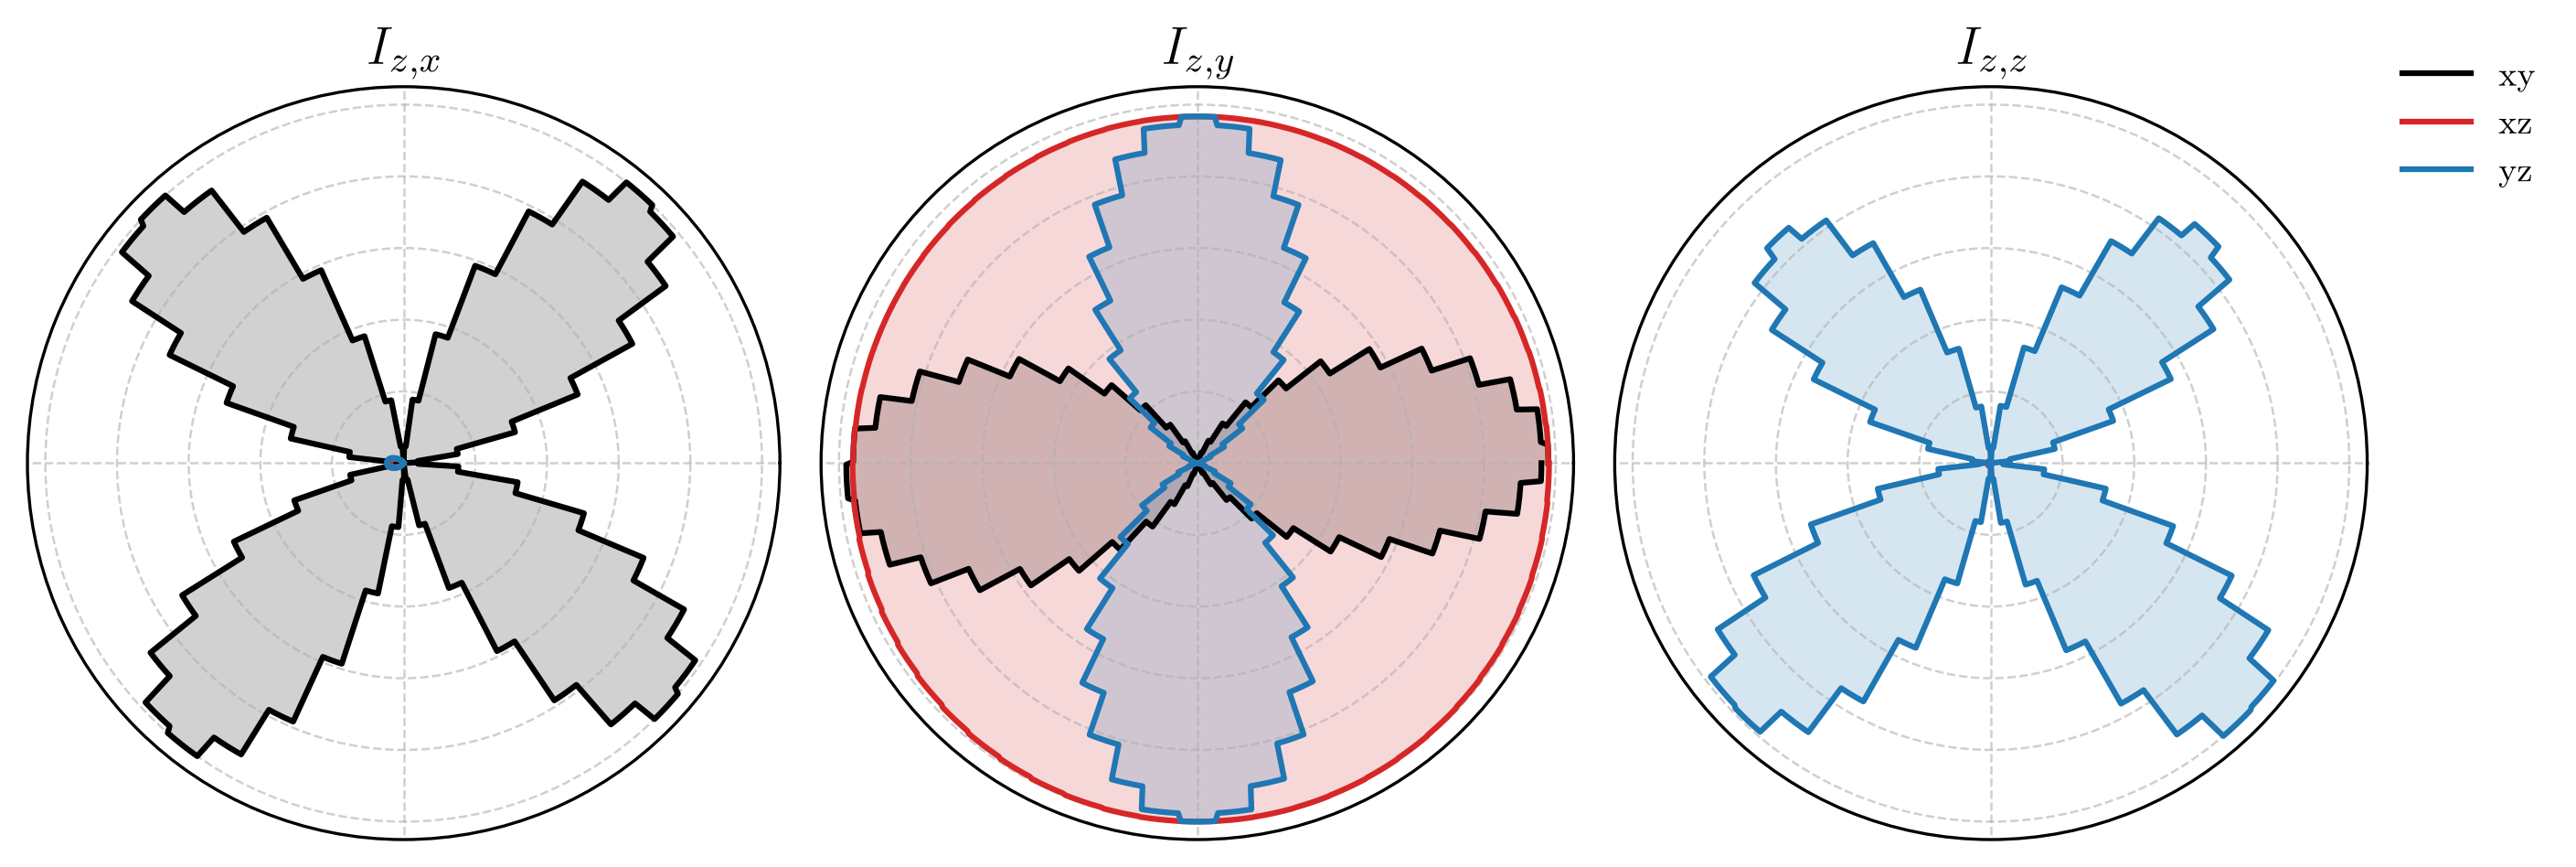

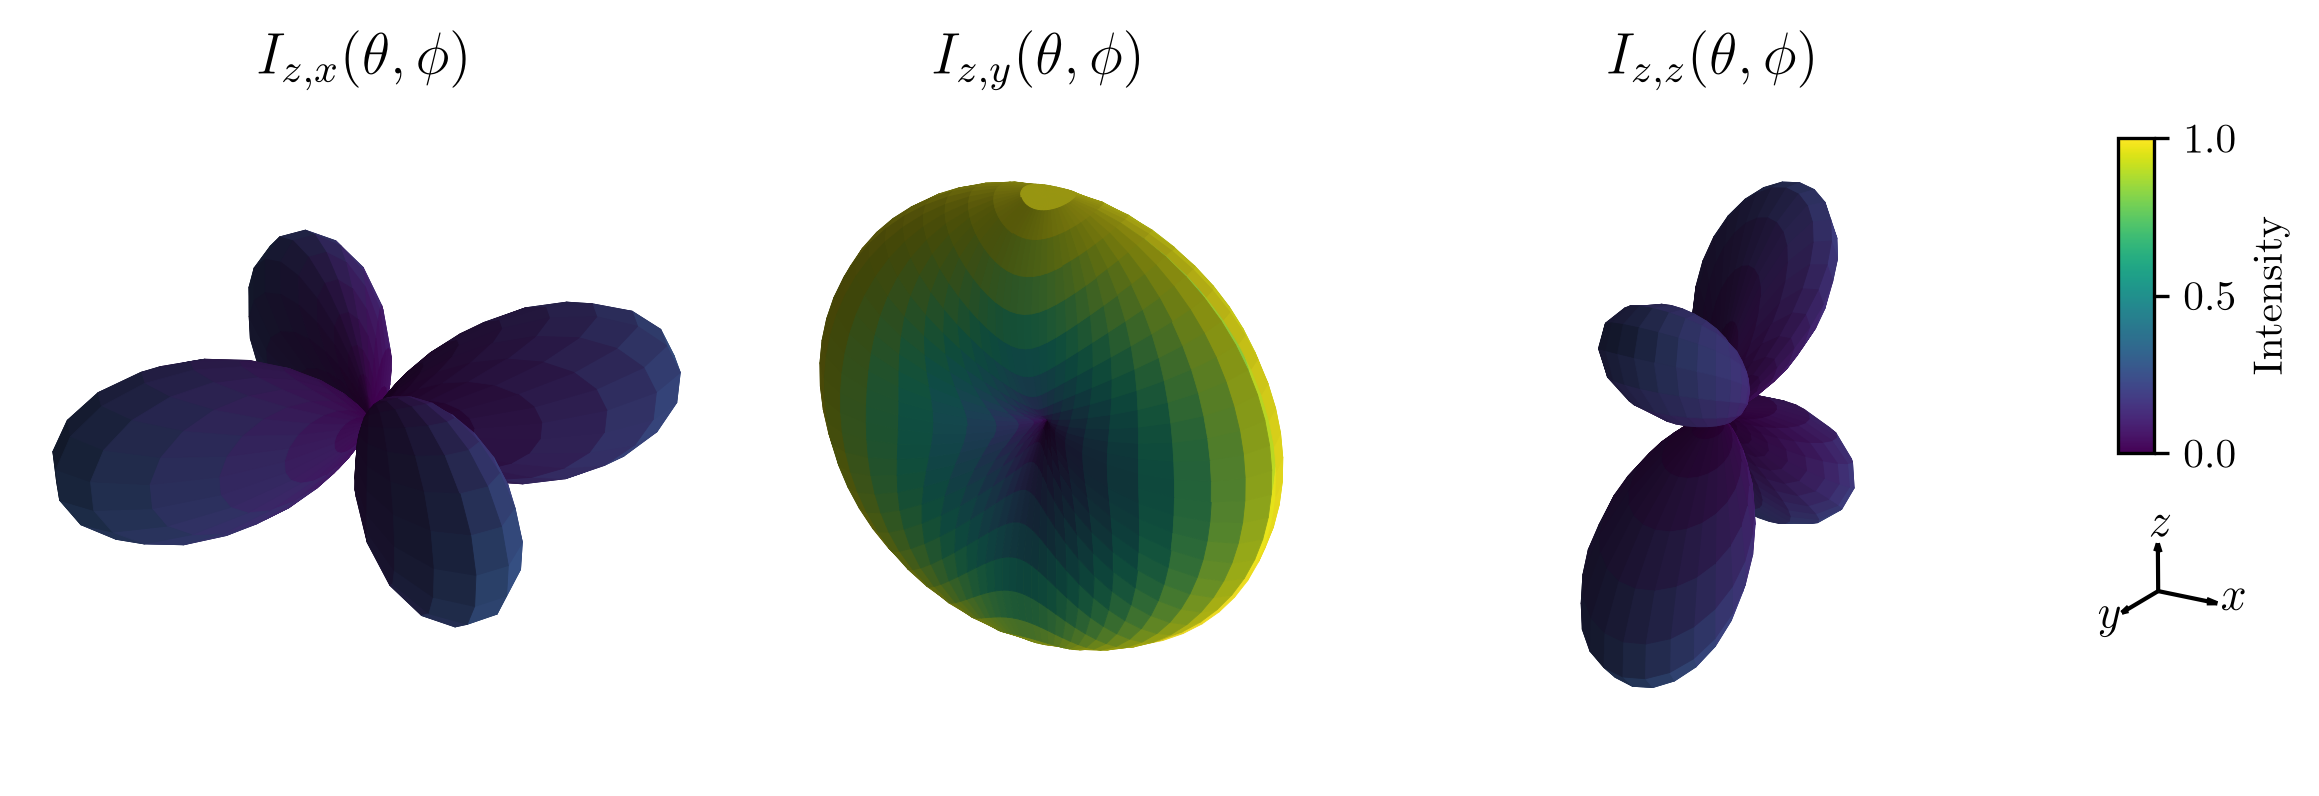

In [8]:
E_lib_plus_z, E_lib_minus_z, dE_lib_z = librational_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=2, angle_deg=angle_deg, 
                                                                       Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_lib_z_total, I_lib_z_Ex, I_lib_z_Ey, I_lib_z_Ez = info_patterns_from_scattered_field(dE=dE_lib_z, delta_mu=angle_deg, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_z_Ex, I_lib_z_Ey, I_lib_z_Ez], labels=["z,x", "z,y", "z,z"], planes=DEFAULT_2D_PLANES, normalize=DEFAULT_2D_NORMALIZE, 
                     fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_z_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_z_Ex, I_lib_z_Ey, I_lib_z_Ez], labels=["z,x", "z,y", "z,z"], cmap=cm.viridis, scale_list=[0.34, 0.34, 0.4], savefig=False, 
                     save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_z_3d", results_dir=results_dir)

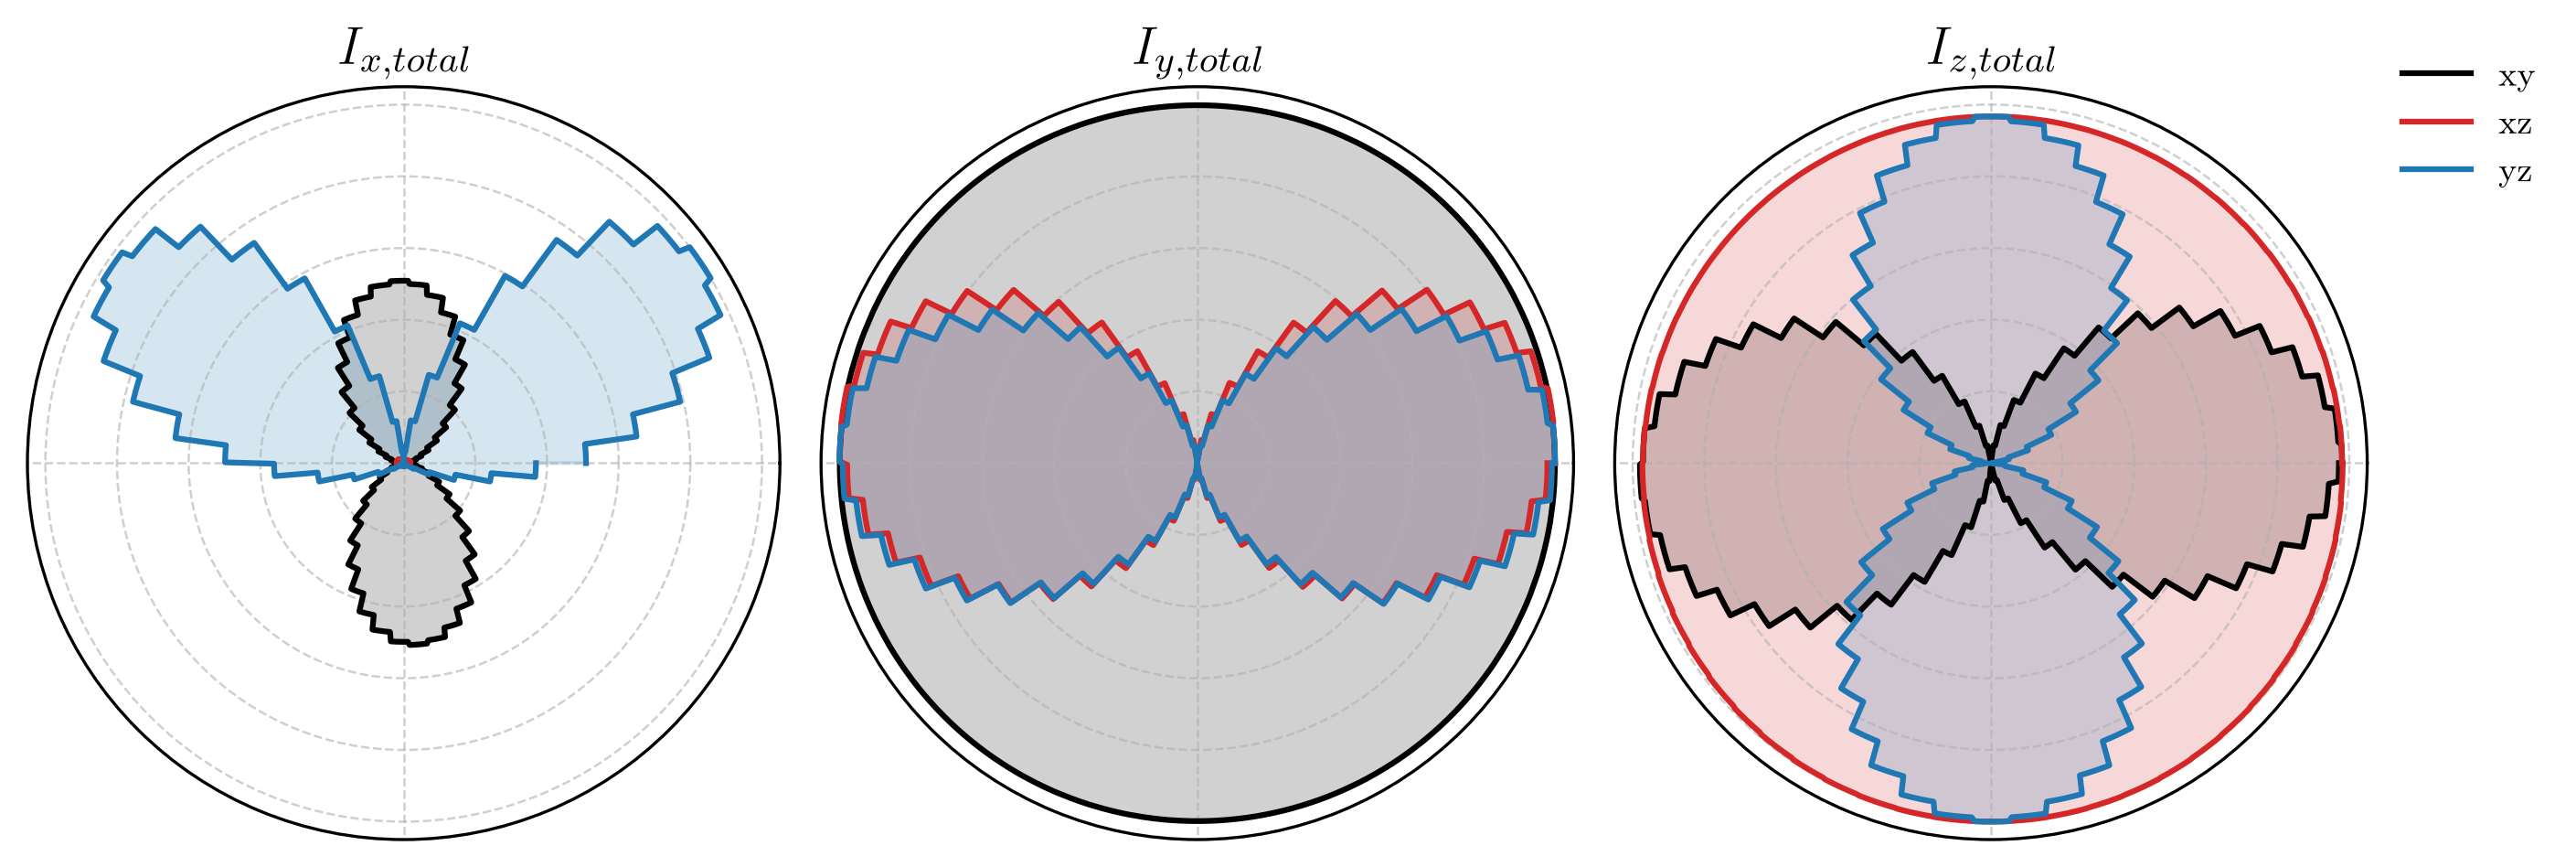

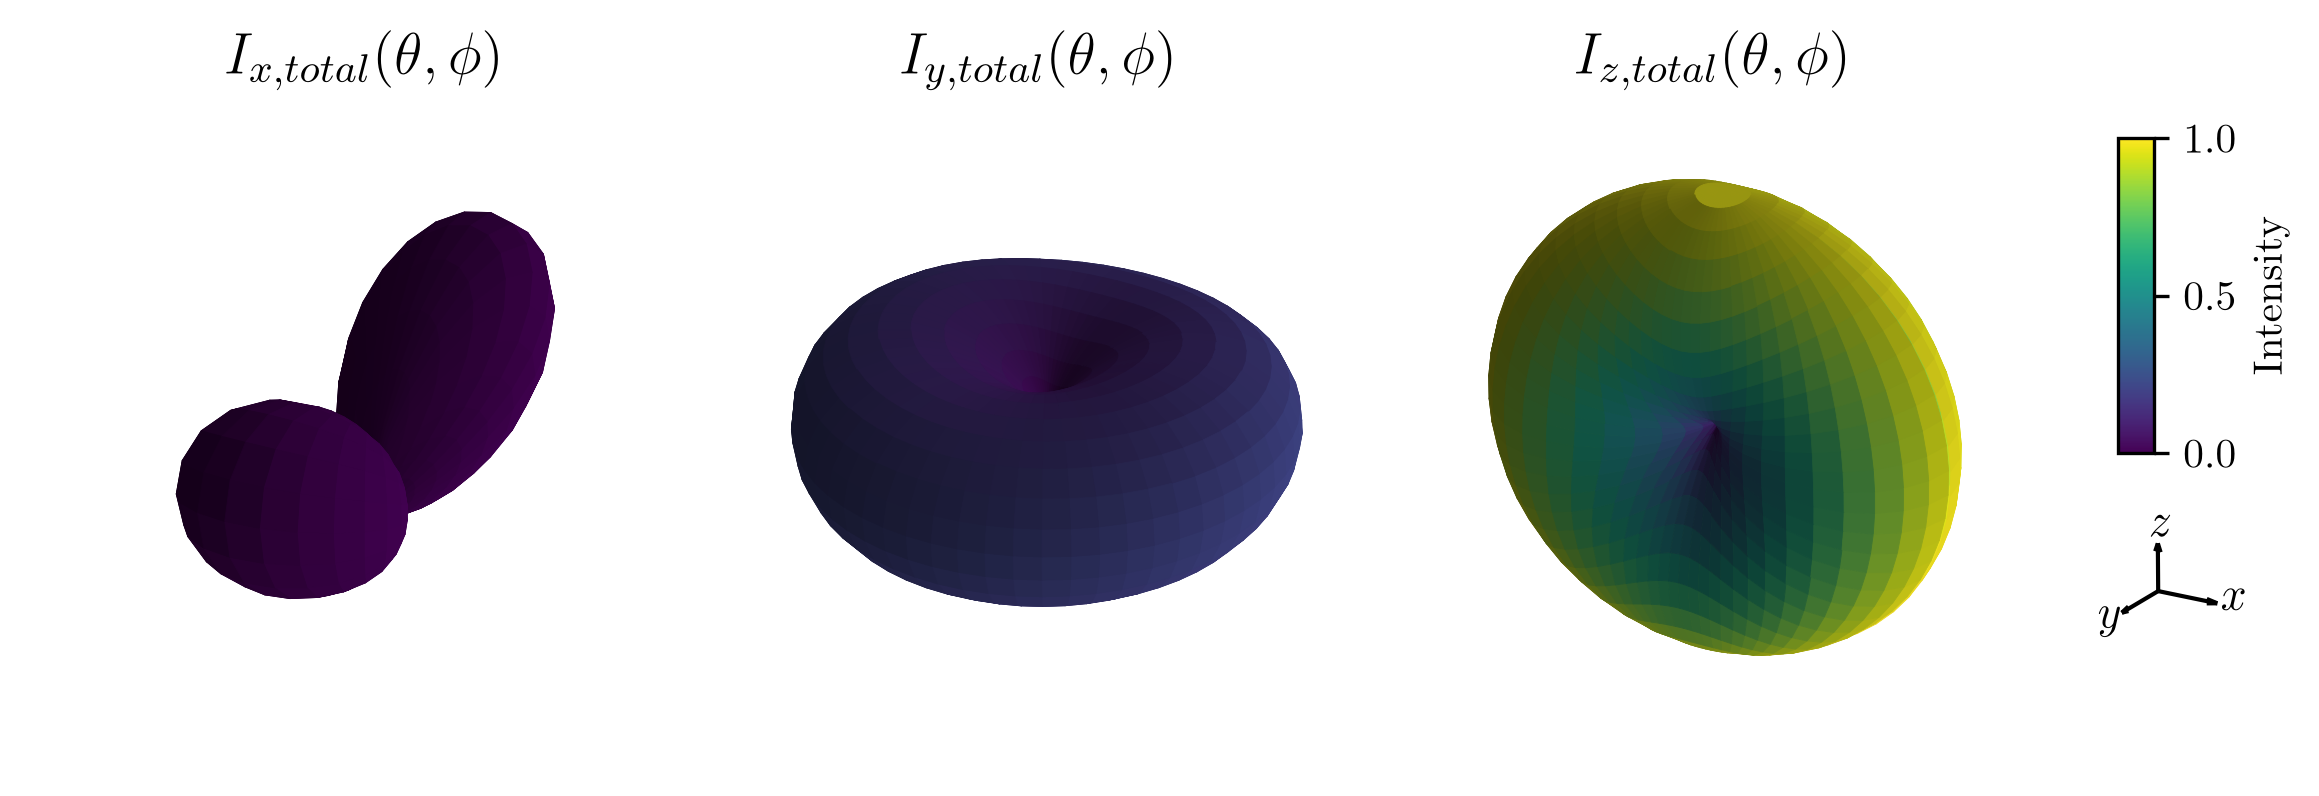

In [9]:
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_total, I_lib_y_total, I_lib_z_total], labels=["x,total", "y,total", "z,total"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_total_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_total, I_lib_y_total, I_lib_z_total], labels=["x,total", "y,total", "z,total"], cmap=cm.viridis, scale_list=[0.28, 0.34, 0.34], 
                     savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_total_3d", results_dir=results_dir)